In [5]:
import pandas as pd
import numpy as np
import time
import json

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns


RANDOM_STATE = 42

In [6]:
X_train = pd.read_csv(f"X_train.csv")
X_val = pd.read_csv(f"X_val.csv")
X_test = pd.read_csv(f"X_test.csv")
y_train = pd.read_csv(f"y_train.csv").values.ravel()
y_val = pd.read_csv(f"y_val.csv").values.ravel()
y_test = pd.read_csv(f"y_test.csv").values.ravel()

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (29274, 49), Val shape: (9758, 49), Test shape: (9758, 49)


In [7]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "SVM (RBF kernel)": SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE),
    "Naive Bayes (Gaussian)": GaussianNB(),
}


In [8]:
#evaluation of important measures
def evaluate(y_true, y_pred):
    
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),   # precision of predicting class 1 (>50K)
        "recall": recall_score(y_true, y_pred),
        "f1_score": f1_score(y_true, y_pred),
    }

In [9]:
val_results = {}
test_results = {}
train_times = {}
confusion_matrices = {}

for name, model in models.items():
    print(f"\nTraining {name} ...")
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    train_times[name] = elapsed
    print(f"  -> trained in {elapsed:.2f} seconds")

    val_preds = model.predict(X_val)
    test_preds = model.predict(X_test)

    val_results[name] = evaluate(y_val, val_preds)
    test_results[name] = evaluate(y_test, test_preds)
    confusion_matrices[name] = confusion_matrix(y_test, test_preds).tolist()

    print(f"  Validation -> Accuracy: {val_results[name]['accuracy']:.4f}, "
          f"Precision: {val_results[name]['precision']:.4f}, "
          f"Recall: {val_results[name]['recall']:.4f}, "
          f"F1: {val_results[name]['f1_score']:.4f}")
    print(f"  Test       -> Accuracy: {test_results[name]['accuracy']:.4f}, "
          f"Precision: {test_results[name]['precision']:.4f}, "
          f"Recall: {test_results[name]['recall']:.4f}, "
          f"F1: {test_results[name]['f1_score']:.4f}")


Training KNN ...
  -> trained in 0.05 seconds
  Validation -> Accuracy: 0.8474, Precision: 0.7138, Recall: 0.6053, F1: 0.6551
  Test       -> Accuracy: 0.8494, Precision: 0.7110, Recall: 0.6246, F1: 0.6650

Training Decision Tree ...
  -> trained in 0.08 seconds
  Validation -> Accuracy: 0.8571, Precision: 0.7577, Recall: 0.5929, F1: 0.6652
  Test       -> Accuracy: 0.8642, Precision: 0.7743, Recall: 0.6109, F1: 0.6829

Training Random Forest ...
  -> trained in 0.76 seconds
  Validation -> Accuracy: 0.8625, Precision: 0.7870, Recall: 0.5835, F1: 0.6701
  Test       -> Accuracy: 0.8709, Precision: 0.8029, Recall: 0.6104, F1: 0.6936

Training Logistic Regression ...
  -> trained in 0.21 seconds
  Validation -> Accuracy: 0.8539, Precision: 0.7380, Recall: 0.6040, F1: 0.6643
  Test       -> Accuracy: 0.8532, Precision: 0.7327, Recall: 0.6092, F1: 0.6653

Training SVM (RBF kernel) ...
  -> trained in 21.90 seconds
  Validation -> Accuracy: 0.8552, Precision: 0.7488, Recall: 0.5946, F1: 0.

In [10]:
# returning the results in form of a table, and saving them as .csv file
val_df = pd.DataFrame(val_results).T
val_df["train_time_seconds"] = pd.Series(train_times)
val_df = val_df.round(4)
val_df.to_csv("validation_results.csv")

test_df = pd.DataFrame(test_results).T
test_df["train_time_seconds"] = pd.Series(train_times)
test_df = test_df.round(4)
test_df.to_csv("test_results.csv")

In [11]:
#test comparison table
print(test_df)

                        accuracy  precision  recall  f1_score  \
KNN                       0.8494     0.7110  0.6246    0.6650   
Decision Tree             0.8642     0.7743  0.6109    0.6829   
Random Forest             0.8709     0.8029  0.6104    0.6936   
Logistic Regression       0.8532     0.7327  0.6092    0.6653   
SVM (RBF kernel)          0.8615     0.7632  0.6113    0.6789   
Naive Bayes (Gaussian)    0.7214     0.4580  0.8934    0.6055   

                        train_time_seconds  
KNN                                 0.0478  
Decision Tree                       0.0844  
Random Forest                       0.7582  
Logistic Regression                 0.2134  
SVM (RBF kernel)                   21.8976  
Naive Bayes (Gaussian)              0.0248  


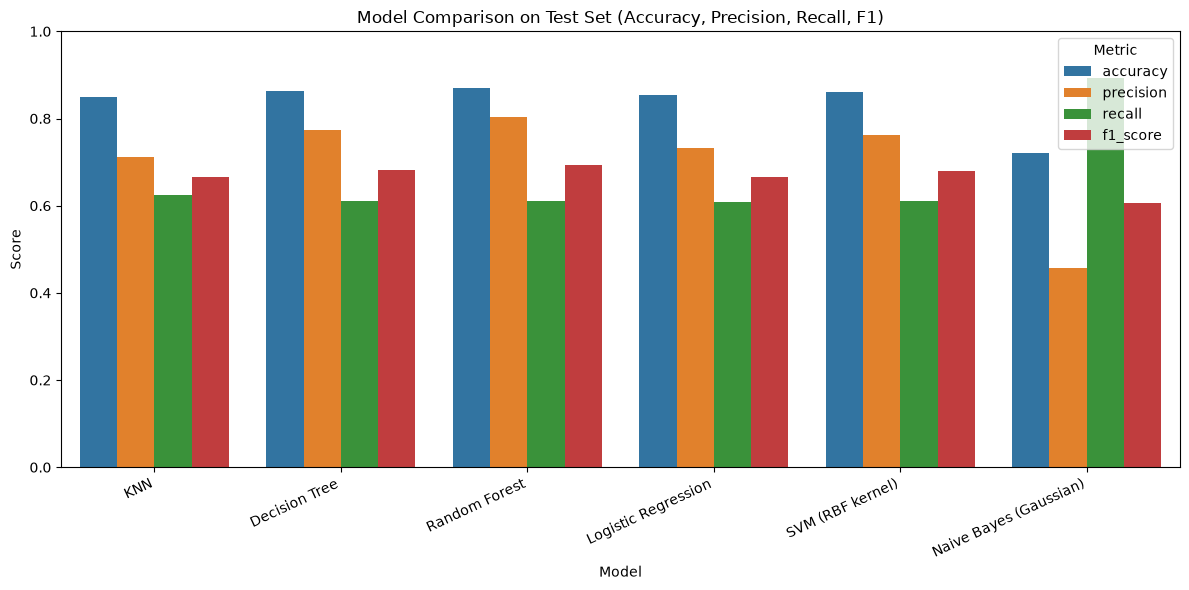

In [12]:
# bar chat to compare accuracy and precission of all the models
plt.figure(figsize=(12, 6))
plot_df = test_df[["accuracy", "precision", "recall", "f1_score"]].reset_index()
plot_df = plot_df.melt(id_vars="index", var_name="metric", value_name="score")
sns.barplot(data=plot_df, x="index", y="score", hue="metric")
plt.xticks(rotation=25, ha="right")
plt.title("Model Comparison on Test Set (Accuracy, Precision, Recall, F1)")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig("06_model_comparison_bar_chart.png", dpi=120)


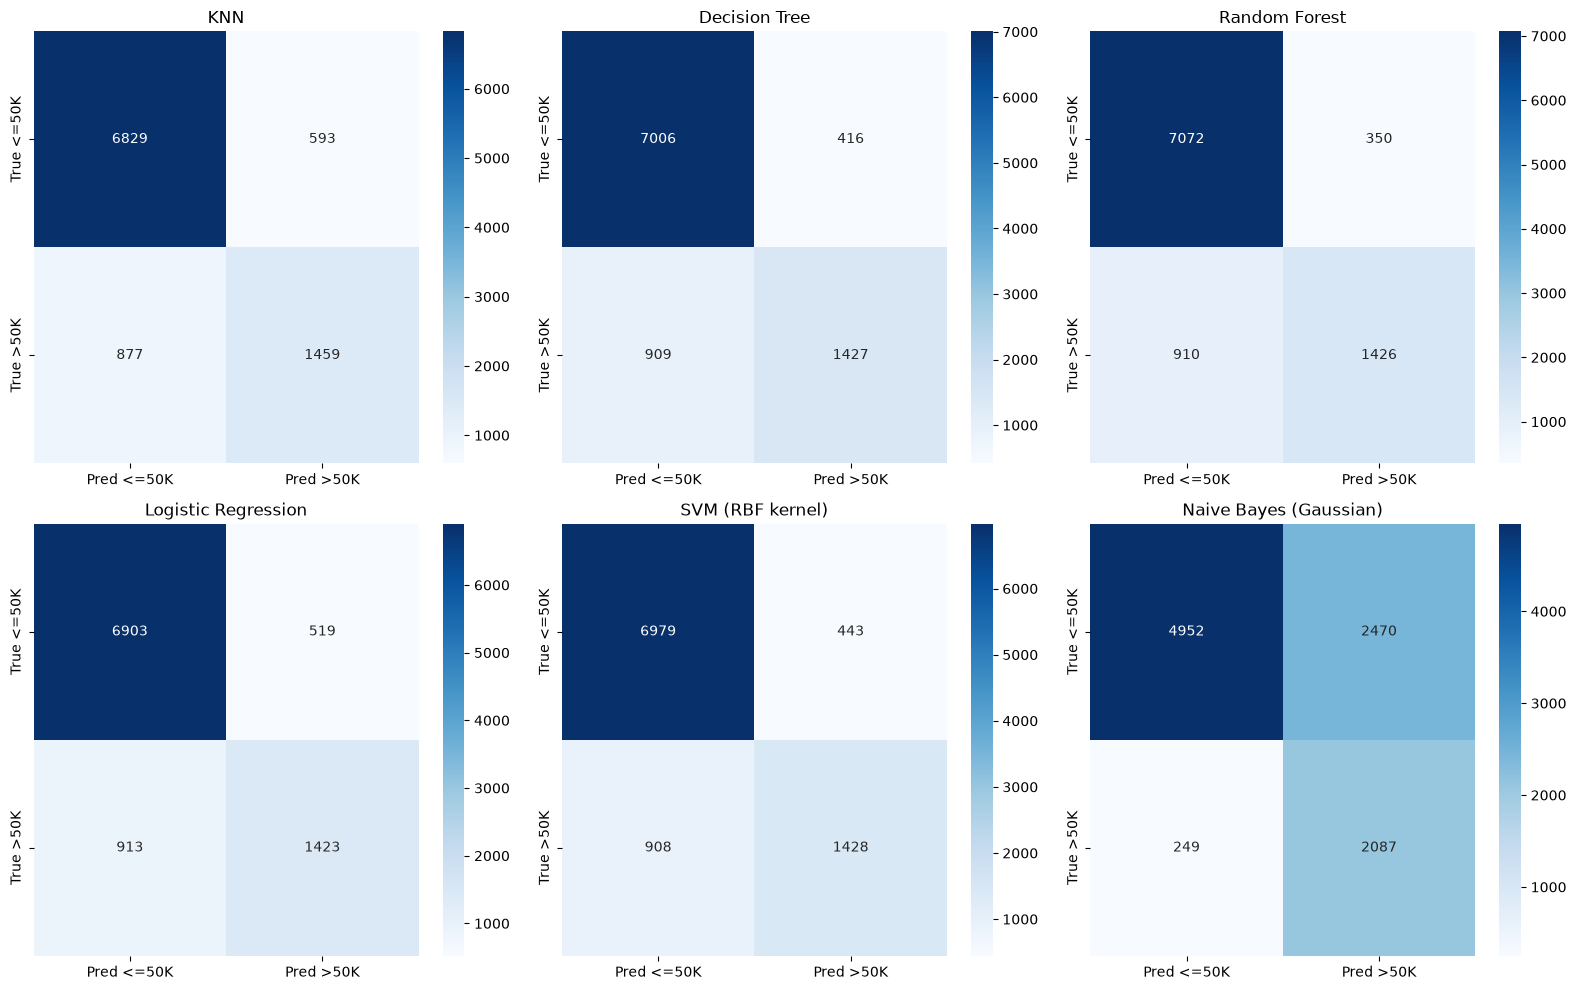

In [14]:
#confusion matrix for all 6 models
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (name, cm) in zip(axes.flatten(), confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred <=50K", "Pred >50K"],
                yticklabels=["True <=50K", "True >50K"])
    ax.set_title(name)
plt.tight_layout()
plt.savefig("07_confusion_matrices.png", dpi=120)


In [15]:

report_lines = []
for name, model in models.items():
    test_preds = model.predict(X_test)
    report_lines.append(f"\n{'=' * 60}\n{name}\n{'=' * 60}")
    report_lines.append(classification_report(y_test, test_preds, target_names=["<=50K", ">50K"]))
print("\n".join(report_lines))


KNN
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90      7422
        >50K       0.71      0.62      0.66      2336

    accuracy                           0.85      9758
   macro avg       0.80      0.77      0.78      9758
weighted avg       0.84      0.85      0.85      9758


Decision Tree
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      7422
        >50K       0.77      0.61      0.68      2336

    accuracy                           0.86      9758
   macro avg       0.83      0.78      0.80      9758
weighted avg       0.86      0.86      0.86      9758


Random Forest
              precision    recall  f1-score   support

       <=50K       0.89      0.95      0.92      7422
        >50K       0.80      0.61      0.69      2336

    accuracy                           0.87      9758
   macro avg       0.84      0.78      0.81      9758
weighted avg       0.87      0.87      